# 01 Data Understanding

Goal:
- Load the AML transaction dataset.
- Inspect schema and class imbalance.
- Build a small sample graph for early graph statistics.

In [1]:
from pathlib import Path
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt

from src.data.load_data import load_transactions
from src.features.graph_features import build_sample_graph, graph_summary

In [3]:
DATA_PATH = Path("../data/raw/HI-Small_Trans.csv")
NROWS = 500_000  # start small; set None when the pipeline works

df = load_transactions(DATA_PATH, nrows=NROWS)
df.head()

,timestamp,from_bank,sender_account,to_bank,receiver_account,amount_received,receiving_currency,amount_paid,payment_currency,payment_format,is_laundering,sender_id,receiver_id
0,2022-09-01,1411,800C81020,2843,801727270,974.63,US Dollar,974.63,US Dollar,Cash,0,1411_800C81020,2843_801727270
1,2022-09-01,318398,81392FC00,318398,81392FC00,5285.34,US Dollar,5285.34,US Dollar,Reinvestment,0,318398_81392FC00,318398_81392FC00
2,2022-09-01,18475,80D6B5440,18475,80D6B5440,70729.11,Yuan,70729.11,Yuan,Reinvestment,0,18475_80D6B5440,18475_80D6B5440
3,2022-09-01,353541,8139376B0,221731,8139349A0,788.65,US Dollar,788.65,US Dollar,ACH,0,353541_8139376B0,221731_8139349A0
4,2022-09-01,317588,8071DF720,317588,8071DF720,9819.65,Ruble,9819.65,Ruble,Reinvestment,0,317588_8071DF720,317588_8071DF720


In [4]:
print("Shape:", df.shape)
display(df.dtypes)
display(df["is_laundering"].value_counts(dropna=False))
display(df["is_laundering"].value_counts(normalize=True))

Shape: (500000, 13)


timestamp             datetime64[us]
from_bank                      int64
sender_account                   str
to_bank                        int64
receiver_account                 str
amount_received              float64
receiving_currency               str
amount_paid                  float64
payment_currency                 str
payment_format                   str
is_laundering                  int64
sender_id                        str
receiver_id                      str
dtype: object

is_laundering
0    499807
1       193
Name: count, dtype: int64

is_laundering
0    0.999614
1    0.000386
Name: proportion, dtype: float64

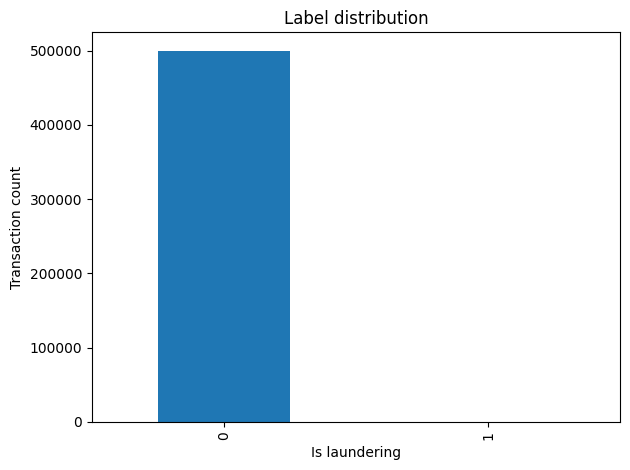

In [5]:
# Label imbalance figure
ax = df["is_laundering"].value_counts().sort_index().plot(kind="bar")
ax.set_title("Label distribution")
ax.set_xlabel("Is laundering")
ax.set_ylabel("Transaction count")
plt.tight_layout()
plt.savefig("../reports/figures/label_distribution.png", dpi=150)
plt.show()

In [6]:
# Basic transaction EDA
for col in ["payment_format", "payment_currency", "receiving_currency"]:
    if col in df.columns:
        print(f"\nTop values for {col}")
        display(df[col].value_counts().head(10))


Top values for payment_format


payment_format
Reinvestment    285394
Cheque           81362
Credit Card      59045
ACH              30531
Cash             21250
Bitcoin          13914
Wire              8504
Name: count, dtype: int64


Top values for payment_currency


payment_currency
US Dollar      190123
Euro           114124
Swiss Franc     23054
Yuan            20712
Shekel          18954
Rupee           18757
UK Pound        16963
Yen             15499
Ruble           15142
Bitcoin         13916
Name: count, dtype: int64


Top values for receiving_currency


receiving_currency
US Dollar      189420
Euro           114387
Swiss Franc     23211
Yuan            20347
Shekel          19072
Rupee           18808
UK Pound        17001
Yen             15557
Ruble           15204
Bitcoin         14013
Name: count, dtype: int64

In [7]:
# Build a sample graph only for quick graph statistics.
G = build_sample_graph(df, max_edges=50_000)
summary = graph_summary(G)
summary

{'nodes': 57099,
 'edges': 48148,
 'density': 1.4768243800818484e-05,
 'weak_components': 44591,
 'largest_weak_component': 362,
 'avg_in_degree': 0.8432371845391338,
 'avg_out_degree': 0.8432371845391338}